# 07 - Final Model, Failure Analysis and Class Ablation

Takes the configuration chosen on validation in notebook 06, reports it once on the
held-out test split, and dissects where it fails.

The class-removal ablation is included because the original submission reported it, but
it is framed the way the reviewers would want: **removing the hardest classes is not a
model improvement.** The full-taxonomy number is the operational one; the ablations only
isolate how much each difficult class costs.

In [1]:
import sys, json
from pathlib import Path
EXPERIMENT_DIR = Path(r"/mnt/b6bdcd1c-136a-435b-aeed-0e1b31c32749/Paper_Reeyan/Experiment")
if str(EXPERIMENT_DIR) not in sys.path:
    sys.path.insert(0, str(EXPERIMENT_DIR))

import numpy as np, pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from dasfe import config as C, fusion as F, evaluate as EV

sns.set_theme(style="whitegrid", context="notebook")

# ----------------------------- CONFIGURE ME -----------------------------
DATASET      = "tomasov"
SMOKE_TEST   = False
USE_SELECTED = False      # report the final model on the consensus subset
# ------------------------------------------------------------------------

suffix    = "_smoke" if SMOKE_TEST else ""
fuse_dir  = C.results_dir(DATASET, "04_fusion" + suffix)
sel_dir   = C.results_dir(DATASET, "05_selection" + suffix)
bench_dir = C.results_dir(DATASET, "06_benchmark/full_1002" + suffix)
final_dir = C.results_dir(DATASET, "07_final" + suffix)

data  = F.load(fuse_dir)
X, y  = data["X"], data["y"]
names = np.array(data["feature_names"])
mani  = data["manifest"]
split = mani["split"].to_numpy()

best_cfg = json.loads((bench_dir / "best_config.json").read_text())
MODEL, STRATEGY = best_cfg["best_model"], best_cfg["best_strategy"]

if USE_SELECTED:
    mask = np.load(sel_dir / "mask_consensus.npy")
    X, names = X[:, mask], names[mask]

print(f"{DATASET}: {MODEL} + {STRATEGY} on {X.shape[1]} features")
classes = sorted(np.unique(y))
print("classes:", classes)

tomasov: LightGBM + borderline_smote on 1002 features
classes: ['car', 'construction', 'fence', 'longboard', 'manipulation', 'openclose', 'regular', 'running', 'walk']


## 1. Final test-set performance

In [2]:
tr, te = split == "train", split == "test"
res = EV.fit_predict(MODEL, STRATEGY, X[tr], y[tr], X[te], y[te], C.SEED)
m = res["metrics"]

headline = pd.DataFrame([{
    "accuracy": 100*m["accuracy"],
    "balanced_accuracy": 100*m["balanced_accuracy"],
    "precision_macro": 100*m["precision_macro"],
    "recall_macro": 100*m["recall_macro"],
    "f1_macro": 100*m["f1_macro"],
    "f1_weighted": 100*m["f1_weighted"],
    "auc_ovr_macro": 100*m.get("auc_ovr_macro", np.nan),
}]).round(2)
display(headline)
print(f"train {m['train_seconds']:.1f}s | inference {m['ms_per_sample']:.4f} ms/sample "
      f"| {1000/max(m['ms_per_sample'],1e-9):.0f} samples/s")

,accuracy,balanced_accuracy,precision_macro,recall_macro,f1_macro,f1_weighted,auc_ovr_macro
0,90.71,81.97,83.38,81.97,81.98,90.07,97.46


train 1357.4s | inference 0.1716 ms/sample | 5829 samples/s


In [3]:
report = EV.per_class_report(y[te], res["y_pred"], labels=classes)
display(report.round(3))
report.to_csv(final_dir / "per_class_report.csv", index=False)

worst = report[report["class"].isin(classes)].nsmallest(3, "f1-score")
print("hardest classes:")
for _, r in worst.iterrows():
    print(f"  {r['class']:14s} F1={r['f1-score']:.3f}  recall={r['recall']:.3f}  "
          f"support={int(r['support'])}")

,class,precision,recall,f1-score,support
0,car,0.817,0.875,0.845,1772.000
1,construction,0.993,0.998,0.996,2232.000
2,fence,0.845,0.947,0.893,1983.000
3,longboard,0.890,0.935,0.912,581.000
4,manipulation,0.986,0.999,0.993,867.000
5,openclose,0.167,0.025,0.044,198.000
6,regular,0.922,0.784,0.847,1111.000
7,running,0.973,0.921,0.946,929.000
8,walk,0.912,0.893,0.903,1661.000
9,accuracy,0.907,0.907,0.907,0.907


hardest classes:
  openclose      F1=0.044  recall=0.025  support=198
  car            F1=0.845  recall=0.875  support=1772
  regular        F1=0.847  recall=0.784  support=1111


## 2. Confusion matrices

Row-normalised, so each row reads as "of the true X events, what fraction were predicted
as each class" - which is the form an operator cares about.

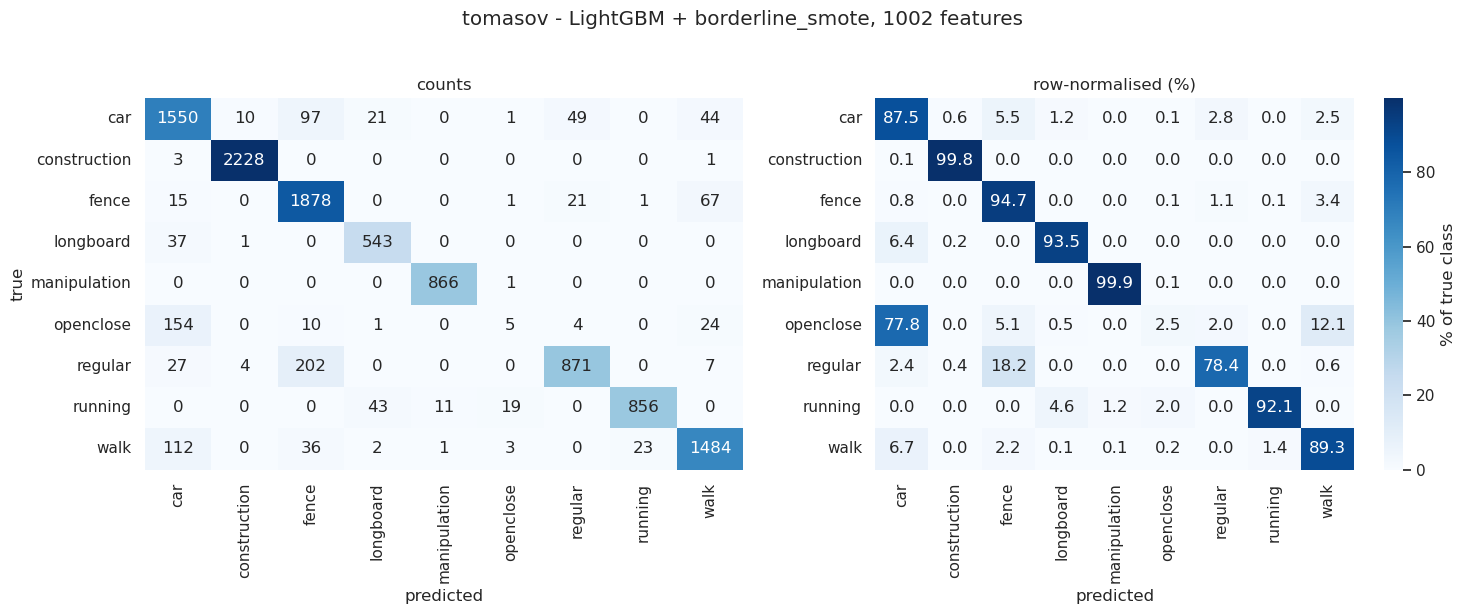

In [4]:
cm_raw = EV.confusion(y[te], res["y_pred"], labels=classes)
cm_norm = EV.confusion(y[te], res["y_pred"], labels=classes, normalize="true")

fig, axes = plt.subplots(1, 2, figsize=(15, 6))
sns.heatmap(cm_raw, annot=True, fmt="d", cmap="Blues", ax=axes[0], cbar=False)
axes[0].set_title("counts"); axes[0].set_xlabel("predicted"); axes[0].set_ylabel("true")
sns.heatmap(100*cm_norm, annot=True, fmt=".1f", cmap="Blues", ax=axes[1],
            cbar_kws={"label": "% of true class"})
axes[1].set_title("row-normalised (%)"); axes[1].set_xlabel("predicted"); axes[1].set_ylabel("")
fig.suptitle(f"{DATASET} - {MODEL} + {STRATEGY}, {X.shape[1]} features", y=1.02)
plt.tight_layout()
plt.savefig(final_dir / "confusion_matrix.png", dpi=200, bbox_inches="tight")
plt.show()

cm_raw.to_csv(final_dir / "confusion_counts.csv")
cm_norm.to_csv(final_dir / "confusion_normalised.csv")

In [5]:
# Dominant error modes, ranked - the material for the failure-analysis paragraph.
errors = []
for t in classes:
    for p in classes:
        if t != p and cm_norm.loc[t, p] > 0:
            errors.append({"true": t, "predicted": p,
                           "pct_of_true": 100*cm_norm.loc[t, p],
                           "n": int(cm_raw.loc[t, p])})
errors = pd.DataFrame(errors).sort_values("pct_of_true", ascending=False)
display(errors.head(10).round(2))
errors.to_csv(final_dir / "error_modes.csv", index=False)

print("\nOperational reading of the top error modes:")
for _, r in errors.head(3).iterrows():
    print(f"  {r.pct_of_true:.1f}% of '{r.true}' events are reported as '{r.predicted}' "
          f"({r.n} of {int(cm_raw.loc[r.true].sum())})")

,true,predicted,pct_of_true,n
16,openclose,car,77.78,154
23,regular,fence,18.18,202
20,openclose,walk,12.12,24
28,walk,car,6.74,112
13,longboard,car,6.37,37
1,car,fence,5.47,97
17,openclose,fence,5.05,10
25,running,longboard,4.63,43
12,fence,walk,3.38,67
4,car,regular,2.77,49



Operational reading of the top error modes:
  77.8% of 'openclose' events are reported as 'car' (154 of 198)
  18.2% of 'regular' events are reported as 'fence' (202 of 1111)
  12.1% of 'openclose' events are reported as 'walk' (24 of 198)


## 3. Feature importance and interpretability

The argument for a handcrafted pipeline over an end-to-end network is auditability, so
this section has to be more than decoration: every important feature has a name, a
domain and a physical meaning.

importance source: LightGBM native


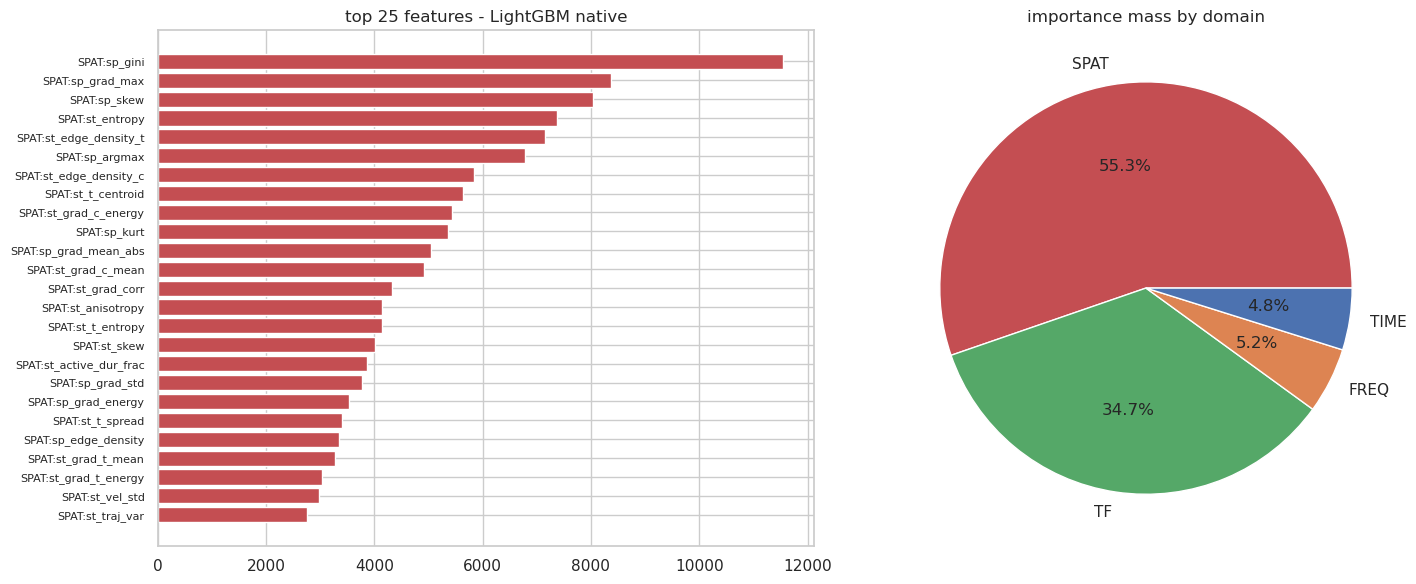

,total_importance,pct
domain,,
SPAT,156738.0,55.3
TF,98414.0,34.7
FREQ,14609.0,5.2
TIME,13739.0,4.8


In [6]:
clf = res["pipeline"].named_steps["clf"]

# Native importances where the estimator exposes them; otherwise permutation
# importance on the test split.  HistGradientBoosting has neither
# `feature_importances_` nor `coef_`, so without this fallback the whole
# section silently produces zeros.
if hasattr(clf, "feature_importances_"):
    imp = np.asarray(clf.feature_importances_, dtype=float)
    imp_kind = f"{MODEL} native"
elif hasattr(clf, "coef_"):
    imp = np.abs(np.asarray(clf.coef_, dtype=float)).mean(axis=0)
    imp_kind = f"{MODEL} |coef|"
else:
    from sklearn.inspection import permutation_importance
    sub = np.random.default_rng(C.SEED).choice(
        int(te.sum()), size=min(2000, int(te.sum())), replace=False)
    pi = permutation_importance(res["pipeline"], X[te][sub], y[te][sub],
                                n_repeats=3, random_state=C.SEED,
                                scoring="f1_macro", n_jobs=C.N_JOBS)
    imp = pi.importances_mean
    imp_kind = "permutation (macro-F1 drop)"
print("importance source:", imp_kind)

fi = pd.DataFrame({"feature": names, "importance": imp})
fi["domain"] = fi.feature.str.split(":").str[0]
fi = fi.sort_values("importance", ascending=False)

fig, axes = plt.subplots(1, 2, figsize=(15, 6))
top = fi.head(25).iloc[::-1]
colors = {"TIME": "#4C72B0", "FREQ": "#DD8452", "TF": "#55A868", "SPAT": "#C44E52"}
axes[0].barh(range(len(top)), top.importance, color=[colors.get(d, "grey") for d in top.domain])
axes[0].set_yticks(range(len(top))); axes[0].set_yticklabels(top.feature, fontsize=8)
axes[0].set_title(f"top 25 features - {imp_kind}")

# Permutation importance can be negative (a shuffled feature that helps);
# clip at zero so the composition chart stays interpretable.
agg = (fi.assign(importance=fi.importance.clip(lower=0))
         .groupby("domain").importance.sum().sort_values(ascending=False))
if agg.sum() > 0:
    axes[1].pie(agg.values, labels=agg.index, autopct="%1.1f%%",
                colors=[colors.get(d, "grey") for d in agg.index])
    axes[1].set_title("importance mass by domain")
else:
    axes[1].text(0.5, 0.5, "no positive importance mass", ha="center", va="center")
    axes[1].axis("off")
plt.tight_layout()
plt.savefig(final_dir / "feature_importance.png", dpi=200)
plt.show()

fi.to_csv(final_dir / "feature_importance.csv", index=False)
display(agg.to_frame("total_importance").assign(
    pct=lambda d: (100*d.total_importance/max(d.total_importance.sum(), 1e-12)).round(1)))

## 4. Class-removal ablation

Progressively drop the hardest classes and re-run the whole train/test cycle. The gains
are reported explicitly as *class-difficulty effects*, not as model improvements.

In [7]:
# Drop order: hardest first, taken from the per-class F1 on the full taxonomy.
drop_order = report[report["class"].isin(classes)].nsmallest(2, "f1-score")["class"].tolist()
print("ablation drop order (hardest first):", drop_order)

ablation = []
for k in range(len(drop_order) + 1):
    dropped = drop_order[:k]
    keep = ~np.isin(y, dropped)
    yk, Xk, sk = y[keep], X[keep], split[keep]
    trk, tek = sk == "train", sk == "test"
    r = EV.fit_predict(MODEL, STRATEGY, Xk[trk], yk[trk], Xk[tek], yk[tek], C.SEED)
    ablation.append({
        "n_classes": len(np.unique(yk)),
        "dropped": ", ".join(dropped) if dropped else "(none)",
        "n_samples": int(keep.sum()),
        "accuracy": 100*r["metrics"]["accuracy"],
        "balanced_accuracy": 100*r["metrics"]["balanced_accuracy"],
        "f1_macro": 100*r["metrics"]["f1_macro"],
    })
ablation = pd.DataFrame(ablation)
ablation["f1_gain_pp"] = (ablation.f1_macro - ablation.f1_macro.iloc[0]).round(2)
display(ablation.round(2))
ablation.to_csv(final_dir / "class_ablation.csv", index=False)

ablation drop order (hardest first): ['openclose', 'car']


,n_classes,dropped,n_samples,accuracy,balanced_accuracy,f1_macro,f1_gain_pp
0,9,(none),172458,90.71,81.97,81.98,0.00
1,8,openclose,166644,92.57,92.35,92.60,10.62
2,7,"openclose, car",137635,94.72,94.48,94.55,12.57


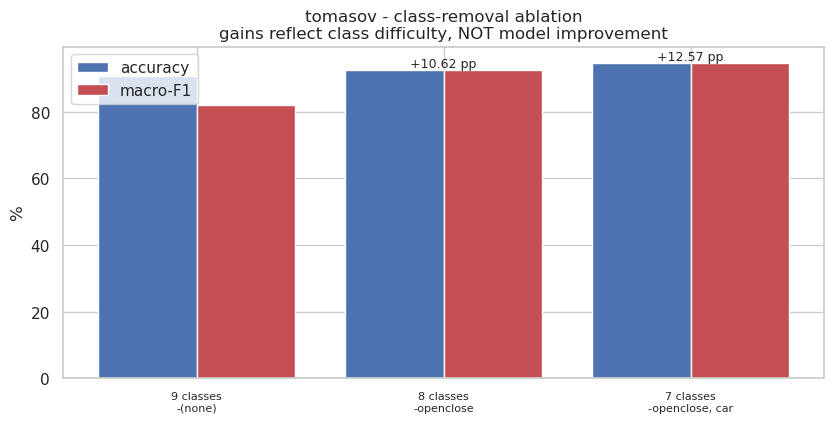

Reportable operational figure (full 9-class taxonomy): 81.98% macro-F1
Cumulative inflation from dropping 2 hard classes: +12.57 pp


In [8]:
fig, ax = plt.subplots(figsize=(8.5, 4.4))
x = np.arange(len(ablation))
ax.bar(x - 0.2, ablation.accuracy, 0.4, label="accuracy", color="#4C72B0")
ax.bar(x + 0.2, ablation.f1_macro, 0.4, label="macro-F1", color="#C44E52")
for i, r in ablation.iterrows():
    if i:
        ax.text(i, max(r.accuracy, r.f1_macro) + 0.8, f"{r.f1_gain_pp:+.2f} pp",
                ha="center", fontsize=9)
ax.set_xticks(x)
ax.set_xticklabels([f"{int(r.n_classes)} classes\n-{r.dropped}" for _, r in ablation.iterrows()],
                   fontsize=8)
ax.set_ylabel("%"); ax.legend()
ax.set_title(f"{DATASET} - class-removal ablation\n"
             "gains reflect class difficulty, NOT model improvement")
plt.tight_layout()
plt.savefig(final_dir / "class_ablation.png", dpi=200)
plt.show()

print(f"Reportable operational figure (full {int(ablation.n_classes.iloc[0])}-class taxonomy): "
      f"{ablation.f1_macro.iloc[0]:.2f}% macro-F1")
print(f"Cumulative inflation from dropping {len(drop_order)} hard classes: "
      f"{ablation.f1_gain_pp.iloc[-1]:+.2f} pp")

## 5. Save the final model card

In [9]:
card = {
    "dataset": DATASET,
    "model": MODEL, "balancing": STRATEGY,
    "n_features": int(X.shape[1]),
    "feature_set": "8/8 consensus" if USE_SELECTED else "full multi-domain",
    "n_classes": len(classes), "classes": classes,
    "n_train": int(tr.sum()), "n_test": int(te.sum()),
    "test": {k: round(100*v, 3) for k, v in m.items()
             if k in ("accuracy", "balanced_accuracy", "precision_macro",
                      "recall_macro", "f1_macro", "f1_weighted")},
    "train_seconds": round(m["train_seconds"], 2),
    "inference_ms_per_sample": round(m["ms_per_sample"], 5),
    "hardest_classes": worst["class"].tolist(),
    "top_error_mode": errors.iloc[0].to_dict() if len(errors) else None,
    "top10_features": fi.head(10).feature.tolist(),
    "ablation_inflation_pp": float(ablation.f1_gain_pp.iloc[-1]),
}
(final_dir / "model_card.json").write_text(json.dumps(card, indent=2, default=str), encoding="utf-8")
headline.to_csv(final_dir / "headline_metrics.csv", index=False)
print(json.dumps(card, indent=2, default=str))

{
  "dataset": "tomasov",
  "model": "LightGBM",
  "balancing": "borderline_smote",
  "n_features": 1002,
  "feature_set": "full multi-domain",
  "n_classes": 9,
  "classes": [
    "car",
    "construction",
    "fence",
    "longboard",
    "manipulation",
    "openclose",
    "regular",
    "running",
    "walk"
  ],
  "n_train": 148229,
  "n_test": 11334,
  "test": {
    "accuracy": 90.709,
    "balanced_accuracy": 81.972,
    "precision_macro": 83.383,
    "recall_macro": 81.972,
    "f1_macro": 81.978,
    "f1_weighted": 90.074
  },
  "train_seconds": 1357.41,
  "inference_ms_per_sample": 0.17157,
  "hardest_classes": [
    "openclose",
    "car",
    "regular"
  ],
  "top_error_mode": {
    "true": "openclose",
    "predicted": "car",
    "pct_of_true": 77.77777777777779,
    "n": 154
  },
  "top10_features": [
    "SPAT:sp_gini",
    "SPAT:sp_grad_max",
    "SPAT:sp_skew",
    "SPAT:st_entropy",
    "SPAT:st_edge_density_t",
    "SPAT:sp_argmax",
    "SPAT:st_edge_density_c",
  

---
**Next:** `08_cross_dataset_generalisation.ipynb` - the two-dataset argument, including a
genuine cross-system transfer experiment on the harmonised event taxonomy.